In [3]:
!pip install transformers accelerate datasets numpy --upgrade
!pip install einops

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import json

# Set your input/output path
base_path = "/content/drive/MyDrive/nvd"
output_path = os.path.join(base_path, "cleaned")
os.makedirs(output_path, exist_ok=True)

# Process files from 2002 to 2024
for year in range(2015, 2025):
    input_file = os.path.join(base_path, f"nvdcve-1.1-{year}.json")
    output_file = os.path.join(output_path, f"nvdcve-cleaned-{year}.json")

    if not os.path.exists(input_file):
        print(f"File not found: {input_file}. Skipping.")
        continue

    with open(input_file, "r", encoding="utf-8") as f:
        data = json.load(f)

    original_count = len(data.get("CVE_Items", []))
    cleaned_items = []

    for item in data["CVE_Items"]:
        descriptions = item["cve"]["description"]["description_data"]
        if any("Rejected reason" in desc["value"] for desc in descriptions):
            continue
        cleaned_items.append(item)

    data["CVE_Items"] = cleaned_items

    with open(output_file, "w", encoding="utf-8") as f_out:
        json.dump(data, f_out, indent=2)

    print(f"{year}: {original_count} -> {len(cleaned_items)} saved to {output_file}")

2015: 1570 -> 902 saved to /content/drive/MyDrive/nvd/cleaned/nvdcve-cleaned-2015.json
2016: 2471 -> 1193 saved to /content/drive/MyDrive/nvd/cleaned/nvdcve-cleaned-2016.json
2017: 6201 -> 3859 saved to /content/drive/MyDrive/nvd/cleaned/nvdcve-cleaned-2017.json
2018: 17489 -> 15861 saved to /content/drive/MyDrive/nvd/cleaned/nvdcve-cleaned-2018.json
2019: 17030 -> 15554 saved to /content/drive/MyDrive/nvd/cleaned/nvdcve-cleaned-2019.json
2020: 20600 -> 18970 saved to /content/drive/MyDrive/nvd/cleaned/nvdcve-cleaned-2020.json
2021: 23070 -> 22249 saved to /content/drive/MyDrive/nvd/cleaned/nvdcve-cleaned-2021.json
2022: 26408 -> 25372 saved to /content/drive/MyDrive/nvd/cleaned/nvdcve-cleaned-2022.json
2023: 29722 -> 29165 saved to /content/drive/MyDrive/nvd/cleaned/nvdcve-cleaned-2023.json
2024: 38257 -> 37588 saved to /content/drive/MyDrive/nvd/cleaned/nvdcve-cleaned-2024.json


In [ ]:
import os
import json

input_dir = "/content/drive/MyDrive/nvd/cleaned"
output_file = "/content/drive/MyDrive/nvd/github_links_2015_2024.json"

results = []

for year in range(2015, 2025):
    input_path = os.path.join(input_dir, f"nvdcve-cleaned-{year}.json")
    if not os.path.exists(input_path):
        print(f"{year} file not found. Skipping.")
        continue

    with open(input_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    for item in data.get("CVE_Items", []):
        cve_id = item["cve"]["CVE_data_meta"]["ID"]
        refs = item["cve"].get("references", {}).get("reference_data", [])
        github_links = [
            ref["url"]
            for ref in refs
            if "github.com" in ref.get("url", "").lower()
        ]
        if github_links:
            results.append({
                "cve_id": cve_id,
                "github_links": github_links
            })

print(f"Extracted {len(results)} CVEs with GitHub links.")
with open(output_file, "w", encoding="utf-8") as f_out:
    json.dump(results, f_out, indent=2)
print(f"Saved to {output_file}")

Extracted 42186 CVEs with GitHub links.
Saved to /content/drive/MyDrive/nvd/github_links_2015_2024.json


In [ ]:
import json
import os
import requests
from urllib.parse import urlparse

# === 路径设置 ===
json_file = "/content/drive/MyDrive/nvd/github_links_2015_2024.json"
output_dir = "patches"
os.makedirs(output_dir, exist_ok=True)

# === 读取 JSON 文件 ===
with open(json_file, "r", encoding="utf-8") as f:
    data = json.load(f)

# === 提取并过滤 commit 链接 ===
def is_valid_commit_link(url):
    return "github.com" in url and "/commit/" in url

# === 抓取 patch 内容 ===
def download_patch(cve_id, url, index):
    try:
        # 清洗链接：移除 fragment
        clean_url = url.split("#")[0]
        patch_url = clean_url + ".patch"
        response = requests.get(patch_url, timeout=10)
        if response.status_code == 200:
            filename = f"{cve_id.replace(':', '-')}_{index}.patch"
            filepath = os.path.join(output_dir, filename)
            with open(filepath, "w", encoding="utf-8") as f:
                f.write(response.text)
            print(f"Saved: {filename}")
        else:
            print(f"Failed: {patch_url} (status: {response.status_code})")
    except Exception as e:
        print(f"Error downloading {url}: {e}")

# === 主程序 ===
for entry in data:
    cve_id = entry["cve_id"]
    links = entry["github_links"]
    for i, link in enumerate(links):
        if is_valid_commit_link(link):
            download_patch(cve_id, link, i)

流式输出内容被截断，只能显示最后 5000 行内容。
Saved: CVE-2023-4897_1.patch
Saved: CVE-2023-4898_0.patch
Saved: CVE-2023-4898_1.patch
Saved: CVE-2023-4899_0.patch
Saved: CVE-2023-4899_1.patch
Saved: CVE-2023-49006_2.patch
Saved: CVE-2023-49006_3.patch
Saved: CVE-2023-49062_0.patch
Saved: CVE-2023-49062_1.patch
Saved: CVE-2023-49075_0.patch
Saved: CVE-2023-49075_1.patch
Failed: https://github.com/pimcore/customer-data-framework/commit/ef7414415cfa64189b8433eff0aa2a9b537a89f7.patch.patch (status: 404)
Failed: https://github.com/pimcore/customer-data-framework/commit/ef7414415cfa64189b8433eff0aa2a9b537a89f7.patch.patch (status: 404)
Saved: CVE-2023-49080_0.patch
Saved: CVE-2023-49080_1.patch
Saved: CVE-2023-49081_2.patch
Saved: CVE-2023-49081_3.patch
Saved: CVE-2023-49082_2.patch
Saved: CVE-2023-49082_3.patch
Saved: CVE-2023-49083_0.patch
Saved: CVE-2023-49083_1.patch
Saved: CVE-2023-49086_0.patch
Saved: CVE-2023-49086_1.patch
Saved: CVE-2023-49087_0.patch
Saved: CVE-2023-49087_1.patch
Saved: CVE-2023-49090_

In [ ]:
import os
import json
import re

# === 路径设置 ===
patch_dir = "/content/patches"
nvd_clean_dir = "/content/drive/MyDrive/nvd/cleaned"  # 你之前保存清洗后的 JSON 路径
output_file = "/content/drive/MyDrive/llm_training_data_2015_2024_with_time.jsonl"

# === 预加载所有 CVE 发布时间 ===
cve_date_map = {}

for year in range(2015, 2025):
    nvd_path = os.path.join(nvd_clean_dir, f"nvdcve-cleaned-{year}.json")
    if not os.path.exists(nvd_path):
        continue
    with open(nvd_path, "r") as f:
        data = json.load(f)
        for item in data.get("CVE_Items", []):
            cve_id = item["cve"]["CVE_data_meta"]["ID"]
            pub_date = item.get("publishedDate", "").split("T")[0]  # 取 YYYY-MM-DD
            cve_date_map[cve_id] = pub_date

# === 主程序：遍历 patch 构建样本并加时间 ===
def extract_functions_from_patch(patch_lines):
    old_code, new_code = [], []
    for line in patch_lines:
        if line.startswith("---") or line.startswith("+++") or line.startswith("@@"):
            continue
        if line.startswith("-") and not line.startswith("--"):
            old_code.append(line[1:].rstrip())
        elif line.startswith("+") and not line.startswith("++"):
            new_code.append(line[1:].rstrip())
    return old_code, new_code

samples = []

for filename in os.listdir(patch_dir):
    if not filename.endswith(".patch"):
        continue

    match = re.search(r"(CVE-\d{4}-\d+)", filename)
    if not match:
        continue
    cve_id = match.group(1)
    pub_date = cve_date_map.get(cve_id, None)
    if not pub_date:
        continue

    file_path = os.path.join(patch_dir, filename)
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    old_code, new_code = extract_functions_from_patch(lines)

    if old_code:
        samples.append({
            "prompt": "Please classify the following function as VULNERABLE or FIXED:\n" + "\n".join(old_code),
            "response": "VULNERABLE",
            "cve_id": cve_id,
            "published": pub_date
        })

    if new_code:
        samples.append({
            "prompt": "Please classify the following function as VULNERABLE or FIXED:\n" + "\n".join(new_code),
            "response": "FIXED",
            "cve_id": cve_id,
            "published": pub_date
        })

# === 保存 ===
with open(output_file, "w", encoding="utf-8") as f:
    for s in samples:
        f.write(json.dumps(s) + "\n")

print(f"补全时间后的样本共保存 {len(samples)} 条 → {output_file}")

补全时间后的样本共保存 44591 条 → /content/drive/MyDrive/llm_training_data_2015_2024_with_time.jsonl


In [5]:
import os
import json
from datetime import datetime
from collections import defaultdict

input_path = "/content/drive/MyDrive/llm_training_data_2015_2024_with_time.jsonl"
output_dir = "/content/drive/MyDrive/test2_wholeyear/temporal_splits_by_time"
os.makedirs(output_dir, exist_ok=True)

buckets = defaultdict(list)

with open(input_path, "r", encoding="utf-8") as f:
    for line in f:
        item = json.loads(line)
        pub_date = item.get("published", "")
        try:
            dt = datetime.strptime(pub_date, "%Y-%m-%d")
            year = dt.year
            if 2015 <= year <= 2024:
                buckets[str(year)].append(item)
        except:
            continue

# 保存每个年份的样本到对应文件
for year, items in buckets.items():
    out_path = os.path.join(output_dir, f"{year}.jsonl")
    with open(out_path, "w", encoding="utf-8") as f:
        for item in items:
            f.write(json.dumps(item) + "\n")
    print(f"{year}: {len(items)} samples saved to {out_path}")

2022: 10239 samples saved to /content/drive/MyDrive/test2_wholeyear/temporal_splits_by_time/2022.jsonl
2020: 3863 samples saved to /content/drive/MyDrive/test2_wholeyear/temporal_splits_by_time/2020.jsonl
2021: 5826 samples saved to /content/drive/MyDrive/test2_wholeyear/temporal_splits_by_time/2021.jsonl
2024: 8360 samples saved to /content/drive/MyDrive/test2_wholeyear/temporal_splits_by_time/2024.jsonl
2023: 9823 samples saved to /content/drive/MyDrive/test2_wholeyear/temporal_splits_by_time/2023.jsonl
2018: 2860 samples saved to /content/drive/MyDrive/test2_wholeyear/temporal_splits_by_time/2018.jsonl
2019: 3198 samples saved to /content/drive/MyDrive/test2_wholeyear/temporal_splits_by_time/2019.jsonl


In [6]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model_name = "microsoft/phi-2"
AutoTokenizer.from_pretrained(model_name)
AutoModelForSequenceClassification.from_pretrained(model_name)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/564M [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some weights of PhiForSequenceClassification were not initialized from the model checkpoint at microsoft/phi-2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


PhiForSequenceClassification(
  (model): PhiModel(
    (embed_tokens): Embedding(51200, 2560)
    (layers): ModuleList(
      (0-31): 32 x PhiDecoderLayer(
        (self_attn): PhiAttention(
          (q_proj): Linear(in_features=2560, out_features=2560, bias=True)
          (k_proj): Linear(in_features=2560, out_features=2560, bias=True)
          (v_proj): Linear(in_features=2560, out_features=2560, bias=True)
          (dense): Linear(in_features=2560, out_features=2560, bias=True)
        )
        (mlp): PhiMLP(
          (activation_fn): NewGELUActivation()
          (fc1): Linear(in_features=2560, out_features=10240, bias=True)
          (fc2): Linear(in_features=10240, out_features=2560, bias=True)
        )
        (input_layernorm): LayerNorm((2560,), eps=1e-05, elementwise_affine=True)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
    )
    (rotary_emb): PhiRotaryEmbedding()
    (embed_dropout): Dropout(p=0.0, inplace=False)
    (final_layernorm): LayerNorm(

In [7]:
from transformers import AutoTokenizer
from datasets import Dataset

model_name = "microsoft/phi-2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

label_map = {"VULNERABLE": 0, "FIXED": 1}

def preprocess(example):
    encoding = tokenizer(
        example["prompt"],
        truncation=True,
        padding="max_length",
        max_length=512
    )
    encoding["label"] = label_map[example["response"]]
    return encoding

In [8]:
def load_and_preprocess_dataset(jsonl_path):
    import pandas as pd
    df = pd.read_json(jsonl_path, lines=True)
    dataset = Dataset.from_pandas(df)
    dataset = dataset.map(preprocess)
    dataset.set_format(type="torch")
    return dataset

In [9]:
from sklearn.metrics import accuracy_score, f1_score

# === 用于 Trainer 的评估函数 ===
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds),
    }

In [10]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from peft import get_peft_model, LoraConfig, TaskType, PeftModel
from sklearn.metrics import classification_report, accuracy_score, f1_score
from datasets import Dataset
from pathlib import Path
import os, csv
import torch
import pandas as pd

# ✅ 年份时间窗口定义（改为全年）
time_steps = [str(y) for y in range(2018, 2025)]  # 2018 ~ 2024

# ✅ 数据路径（使用你展示的文件结构）
model_name = "microsoft/phi-2"
base_data_dir = "/content/drive/MyDrive/test2_wholeyear/temporal_splits_by_time"
base_output_dir = "/content/drive/MyDrive/test2_wholeyear/phi2_lora_time_models_yearly"
Path(base_output_dir).mkdir(parents=True, exist_ok=True)

# 加载 tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.pad_token or tokenizer.eos_token

# LoRA 配置
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.SEQ_CLS,
)

# 数据加载与处理
def load_and_preprocess_dataset(path):
    df = pd.read_json(path, lines=True)
    df = df[df["prompt"].str.len() > 10]
    df = df[df["response"].isin(["VULNERABLE", "FIXED"])]
    label_map = {"VULNERABLE": 0, "FIXED": 1}
    df["label"] = df["response"].map(label_map)
    dataset = Dataset.from_pandas(df[["prompt", "label"]])
    return dataset.map(lambda x: tokenizer(x["prompt"], truncation=True, padding="max_length", max_length=512), batched=True).remove_columns(["prompt"])

# 指标函数
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds),
    }

# 初始化日志文件
metrics_log_path = f"{base_output_dir}/metrics_log.csv"
if not os.path.exists(metrics_log_path):
    with open(metrics_log_path, "w", newline="") as f:
        csv.writer(f).writerow(["train_window", "eval_window", "direction", "accuracy", "f1"])

# 时间滑动训练+评估循环（按年滑动）
for i in range(len(time_steps) - 1):
    train_tag = time_steps[i]
    eval_tag = time_steps[i + 1]
    save_dir = f"{base_output_dir}/{train_tag}"
    Path(save_dir).mkdir(parents=True, exist_ok=True)

    print("=" * 60)
    print(f"Training on: {train_tag} → Evaluating on: {eval_tag}")
    print("=" * 60)

    # 模型加载
    base_model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2,
        torch_dtype=torch.float32,
        local_files_only=True
    )
    base_model.config.pad_token_id = tokenizer.pad_token_id

    if i == 0:
        model = get_peft_model(base_model, peft_config)
    else:
        adapter_path = f"{base_output_dir}/{time_steps[i - 1]}"
        model = PeftModel.from_pretrained(
            model=base_model,
            model_id=adapter_path,
            device_map=None,
            local_files_only=True,
            torch_dtype=torch.float32
        )

    model.gradient_checkpointing_enable()
    model = model.to("cuda")

    # 参数设定
    training_args = TrainingArguments(
        output_dir=save_dir,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        num_train_epochs=3,
        learning_rate=2e-4,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        logging_dir=f"{save_dir}/logs",
        report_to="none",
        fp16=False,
    )

    # 加载数据
    train_dataset = load_and_preprocess_dataset(f"{base_data_dir}/{train_tag}.jsonl")
    eval_dataset = load_and_preprocess_dataset(f"{base_data_dir}/{eval_tag}.jsonl")

    # Trainer 初始化与训练
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    model.save_pretrained(save_dir)
    tokenizer.save_pretrained(save_dir)

    # 正向评估
    preds = trainer.predict(eval_dataset)
    y_true, y_pred = preds.label_ids, preds.predictions.argmax(-1)
    report = classification_report(y_true, y_pred, target_names=["VULNERABLE", "FIXED"])
    print(report)
    with open(f"{save_dir}/eval.txt", "w") as f:
        f.write(report)
    with open(metrics_log_path, "a", newline="") as f:
        csv.writer(f).writerow([train_tag, eval_tag, "forward", accuracy_score(y_true, y_pred), f1_score(y_true, y_pred)])

    # 反向评估（对上一个窗口再评估一遍）
    if i > 0:
        prev_eval_dataset = load_and_preprocess_dataset(f"{base_data_dir}/{time_steps[i - 1]}.jsonl")
        prev_preds = trainer.predict(prev_eval_dataset)
        prev_y_true = prev_preds.label_ids
        prev_y_pred = prev_preds.predictions.argmax(-1)
        prev_report = classification_report(prev_y_true, prev_y_pred, target_names=["VULNERABLE", "FIXED"])
        print(f"\n==== Evaluation on Previous Window: {time_steps[i - 1]} ====")
        print(prev_report)
        with open(f"{save_dir}/eval_prev.txt", "w") as f:
            f.write(prev_report)
        with open(metrics_log_path, "a", newline="") as f:
            csv.writer(f).writerow([train_tag, time_steps[i - 1], "backward", accuracy_score(prev_y_true, prev_y_pred), f1_score(prev_y_true, prev_y_pred)])

# 释放资源
del model
del base_model
torch.cuda.empty_cache()
import gc
gc.collect()

Training on: 2018 → Evaluating on: 2019


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some weights of PhiForSequenceClassification were not initialized from the model checkpoint at microsoft/phi-2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/2860 [00:00<?, ? examples/s]

Map:   0%|          | 0/3198 [00:00<?, ? examples/s]

...

/usr/local/lib/python3.11/dist-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


              precision    recall  f1-score   support

  VULNERABLE       0.67      0.59      0.63      3978
       FIXED       0.66      0.73      0.70      4382

    accuracy                           0.66      8360
   macro avg       0.66      0.66      0.66      8360
weighted avg       0.66      0.66      0.66      8360



Map:   0%|          | 0/10239 [00:00<?, ? examples/s]


==== Evaluation on Previous Window: 2022 ====
              precision    recall  f1-score   support

  VULNERABLE       0.69      0.68      0.69      4764
       FIXED       0.73      0.73      0.73      5475

    accuracy                           0.71     10239
   macro avg       0.71      0.71      0.71     10239
weighted avg       0.71      0.71      0.71     10239



24925

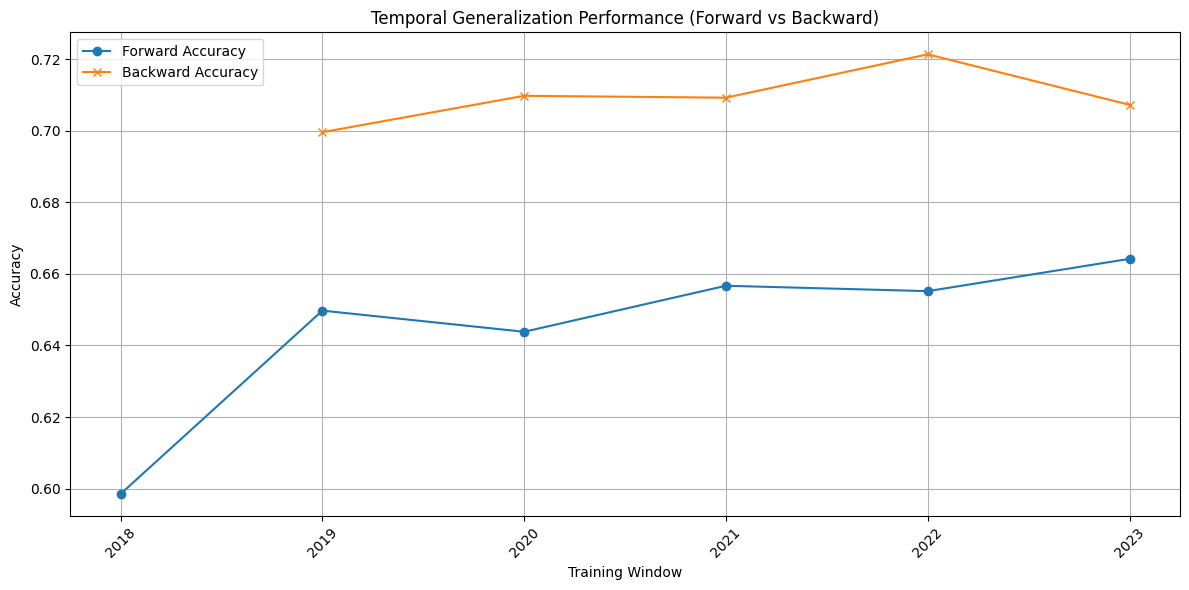

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/test2_wholeyear/phi2_lora_time_models_yearly/metrics_log.csv')

forward_df = df[df['direction'] == 'forward']
backward_df = df[df['direction'] == 'backward']

plt.figure(figsize=(12, 6))
plt.plot(forward_df['train_window'], forward_df['accuracy'], label='Forward Accuracy', marker='o')
plt.plot(backward_df['train_window'], backward_df['accuracy'], label='Backward Accuracy', marker='x')
plt.xticks(rotation=45)
plt.grid(True)
plt.xlabel("Training Window")
plt.ylabel("Accuracy")
plt.title("Temporal Generalization Performance (Forward vs Backward)")
plt.legend()
plt.tight_layout()
plt.show()